In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import clickhouse_connect
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
print("✅ Imports OK")

✅ Imports OK


In [59]:
client = clickhouse_connect.get_client(
    host='clickhouse', port=8123,
    user='default', password='clickhouse123',
    database='gold'
)

df = client.query_df("""
SELECT
    d.Year                              AS year,
    d.Month                             AS month,
    d.Quarter                           AS quarter,
    SUM(f.LinePrice)                    AS total_sales,
    SUM(f.Quantity)                     AS total_quantity,
    COUNT(DISTINCT f.DocumentCode)      AS nb_documents,
    COUNT(DISTINCT f.ClientSK)          AS nb_clients,
    COUNT(DISTINCT f.ItemSK)            AS nb_produits,
    COUNT(DISTINCT f.GeographicalAreaSK) AS nb_regions,
    COUNT(DISTINCT f.WarehouseSK)       AS nb_warehouses,
    AVG(f.DiscountPercentage)           AS avg_discount,
    SUM(f.DiscountAmount)               AS total_discount,
    SUM(f.CostPrice)                    AS total_cost,
    SUM(f.LinePrice - f.CostPrice)      AS total_marge
FROM gold.fact_sales AS f
JOIN gold.dim_date AS d ON f.DateSK = d.DateSK
WHERE f.DocumentTypeSK IN (4, 1, 5)
  AND f.LinePrice IS NOT NULL
GROUP BY year, month, quarter
ORDER BY year, month
""")

df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))
print(f"✅ {len(df)} mois chargés")
df.head()

✅ 51 mois chargés


,year,month,quarter,total_sales,total_quantity,nb_documents,nb_clients,nb_produits,nb_regions,nb_warehouses,avg_discount,total_discount,total_cost,total_marge,date
0,2021,3,1,404.06,6,1,1,6,1,2,15.00,60.61,334.97,69.09,2021-03-01
1,2022,1,1,"591,407.94",10983,1125,197,3225,9,3,9.28,"44,802.24","604,390.30","-12,982.36",2022-01-01
2,2022,2,1,"576,097.45",10770,1263,190,3327,9,3,9.69,"36,225.76","677,038.55","-100,941.11",2022-02-01
3,2022,3,1,"680,213.89",11488,1304,200,3497,9,3,7.93,"40,184.68","683,998.33","-3,784.44",2022-03-01
4,2022,4,2,"650,789.55",11385,1093,224,3264,9,4,9.09,"47,939.71","638,230.19","12,559.35",2022-04-01


In [60]:
print(f"Avant nettoyage : {len(df)} mois")
print(f"Mois incomplets :")
print(df[
    (df['date'] < '2022-01-01') | (df['date'] >= '2026-01-01')
][['date', 'total_sales']].to_string(index=False))

df = df[
    (df['date'] >= '2022-01-01') & (df['date'] < '2026-01-01')
].reset_index(drop=True)

print(f"\nAprès nettoyage : {len(df)} mois")
print(f"Période : {df['date'].min().strftime('%b %Y')} → {df['date'].max().strftime('%b %Y')}")

Avant nettoyage : 51 mois
Mois incomplets :
      date  total_sales
2021-03-01       404.06
2026-01-01 1,218,358.52
2026-02-01   114,247.11

Après nettoyage : 48 mois
Période : Jan 2022 → Dec 2025


In [61]:
# Variables directement disponibles sans feature engineering complexe
# On garde ce qui est métier-pertinent et statistiquement corrélé à total_sales

df_ml = df[[
    'date',
    'year',
    'month',
    'quarter',
    'total_sales',      # ← TARGET
    'total_quantity',   # ← corrélé au CA
    'nb_documents',     # ← volume d'activité
    'nb_clients',       # ← nombre de clients actifs
]].copy()

# Variables temporelles simples
df_ml['semester'] = df_ml['month'].apply(lambda x: 1 if x <= 6 else 2)
df_ml['is_summer']   = df_ml['month'].isin([7, 8]).astype(int)
df_ml['is_end_year'] = df_ml['month'].isin([11, 12]).astype(int)
df_ml['is_january']  = (df_ml['month'] == 1).astype(int)

# Lag features — uniquement les plus pertinents
df_ml['lag_1']  = df_ml['total_sales'].shift(1)
df_ml['lag_12'] = df_ml['total_sales'].shift(12)  # même mois année précédente
df_ml['rolling_mean_3'] = df_ml['total_sales'].shift(1).rolling(3).mean()

# Supprimer les NaN dus aux lags
df_ml = df_ml.dropna().reset_index(drop=True)

print(f"✅ Dataset prêt : {df_ml.shape}")
print(f"Période : {df_ml['date'].min().strftime('%b %Y')} → {df_ml['date'].max().strftime('%b %Y')}")
df_ml.head()

✅ Dataset prêt : (36, 15)
Période : Jan 2023 → Dec 2025


,date,year,month,quarter,total_sales,total_quantity,nb_documents,nb_clients,semester,is_summer,is_end_year,is_january,lag_1,lag_12,rolling_mean_3
0,2023-01-01,2023,1,1,"1,037,923.46",16598,1380,223,1,0,0,1,"985,659.74","591,407.94","960,005.64"
1,2023-02-01,2023,2,1,"939,044.09",15537,1280,227,1,0,0,0,"1,037,923.46","576,097.45","993,566.44"
2,2023-03-01,2023,3,1,"948,325.79",15961,1392,240,1,0,0,0,"939,044.09","680,213.89","987,542.43"
3,2023-04-01,2023,4,2,"913,161.55",17831,1237,235,1,0,0,0,"948,325.79","650,789.55","975,097.78"
4,2023-05-01,2023,5,2,"1,184,666.29",20290,1514,246,1,0,0,0,"913,161.55","734,335.68","933,510.47"


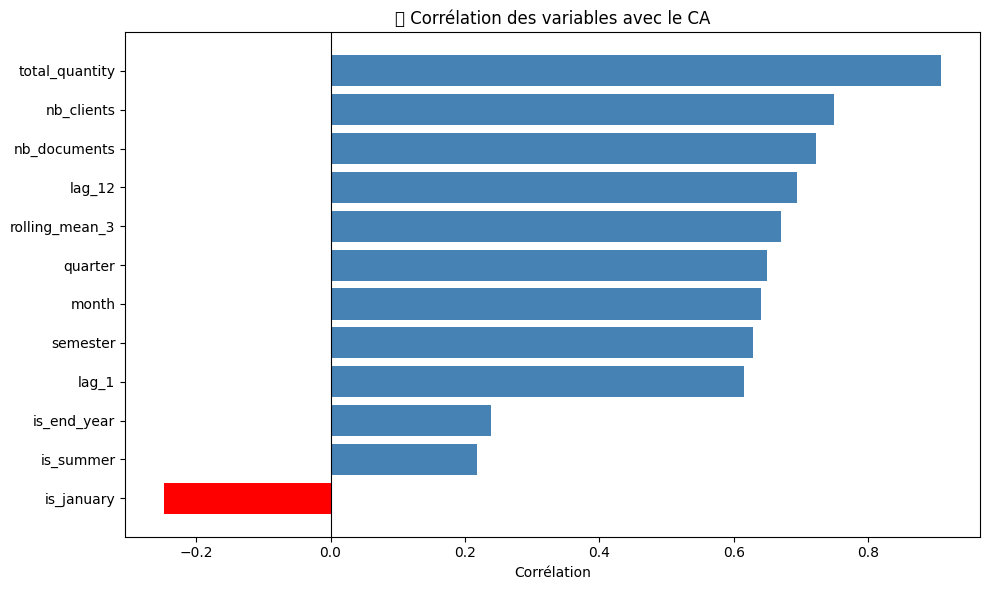


Corrélations :
is_january       -0.25
is_summer         0.22
is_end_year       0.24
lag_1             0.61
semester          0.63
month             0.64
quarter           0.65
rolling_mean_3    0.67
lag_12            0.69
nb_documents      0.72
nb_clients        0.75
total_quantity    0.91


In [62]:
FEATURES = [
    'month', 'quarter', 'semester',
    'total_quantity', 'nb_documents', 'nb_clients',
    'is_summer', 'is_end_year', 'is_january',
    'lag_1', 'lag_12', 'rolling_mean_3'
]
TARGET = 'total_sales'

corr = df_ml[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['red' if v < 0 else 'steelblue' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('📊 Corrélation des variables avec le CA')
ax.set_xlabel('Corrélation')
plt.tight_layout()
plt.show()

print("\nCorrélations :")
print(corr.to_string())

In [63]:
# Garder uniquement les variables avec |corrélation| > 0.1
threshold = 0.3
selected = corr[abs(corr) > threshold].index.tolist()

print(f"Variables sélectionnées ({len(selected)}) :")
for f in selected:
    print(f"  • {f:<20} corr = {corr[f]:.3f}")

FEATURES_FINAL = selected
X = df_ml[FEATURES_FINAL]
y = df_ml[TARGET]

print(f"\nX shape : {X.shape}")
print(f"y shape : {y.shape}")

Variables sélectionnées (9) :
  • lag_1                corr = 0.614
  • semester             corr = 0.628
  • month                corr = 0.640
  • quarter              corr = 0.650
  • rolling_mean_3       corr = 0.670
  • lag_12               corr = 0.694
  • nb_documents         corr = 0.723
  • nb_clients           corr = 0.750
  • total_quantity       corr = 0.908

X shape : (36, 9)
y shape : (36,)


In [64]:
df_ml.to_csv('/app/notebooks/ml_dataset.csv', index=False)

# Sauvegarder aussi la liste des features sélectionnées
import json
with open('/app/notebooks/selected_features.json', 'w') as f:
    json.dump(FEATURES_FINAL, f)

print(f"✅ Dataset sauvegardé → {df_ml.shape}")
print(f"✅ Features sauvegardées → {FEATURES_FINAL}")

✅ Dataset sauvegardé → (36, 15)
✅ Features sauvegardées → ['lag_1', 'semester', 'month', 'quarter', 'rolling_mean_3', 'lag_12', 'nb_documents', 'nb_clients', 'total_quantity']


# train

In [65]:
df_ml = pd.read_csv('/app/notebooks/ml_dataset.csv', parse_dates=['date'])

with open('/app/notebooks/selected_features.json') as f:
    FEATURES = json.load(f)

TARGET = 'total_sales'

X = df_ml[FEATURES]
y = df_ml[TARGET]

print(f"✅ Dataset : {df_ml.shape}")
print(f"✅ Features ({len(FEATURES)}) : {FEATURES}")
print(f"Période : {df_ml['date'].min().strftime('%b %Y')} → {df_ml['date'].max().strftime('%b %Y')}")

✅ Dataset : (36, 15)
✅ Features (9) : ['lag_1', 'semester', 'month', 'quarter', 'rolling_mean_3', 'lag_12', 'nb_documents', 'nb_clients', 'total_quantity']
Période : Jan 2023 → Dec 2025


In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.tree import DecisionTreeRegressor


warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)

print("✅ Imports OK")

✅ Imports OK


Train : 32 mois (Jan 2023 → Aug 2025)
Test  : 4 mois (Sep 2025 → Dec 2025)

✅ Scaler appliqué
   X_train_sc : (32, 9)
   X_test_sc  : (4, 9)


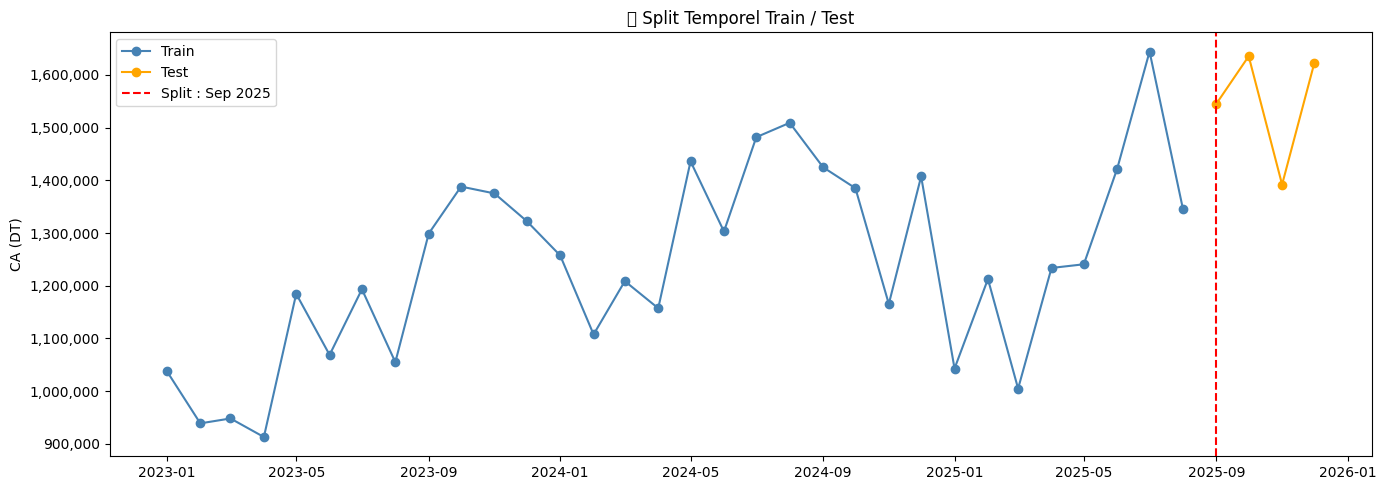

In [67]:
# 80% train / 20% test — en respectant l'ordre temporel
split_idx = int(len(df_ml) * 0.9)
split_date = df_ml.iloc[split_idx]['date']

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

df_train = df_ml.iloc[:split_idx]
df_test  = df_ml.iloc[split_idx:]

print(f"Train : {len(X_train)} mois ({df_train['date'].min().strftime('%b %Y')} → {df_train['date'].max().strftime('%b %Y')})")
print(f"Test  : {len(X_test)} mois ({df_test['date'].min().strftime('%b %Y')} → {df_test['date'].max().strftime('%b %Y')})")

# ── Normalisation ──────────────────────────────────────────────
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\n✅ Scaler appliqué")
print(f"   X_train_sc : {X_train_sc.shape}")
print(f"   X_test_sc  : {X_test_sc.shape}")   

# Visualiser le split
fig, ax = plt.subplots()
ax.plot(df_train['date'], y_train, label='Train', color='steelblue', marker='o')
ax.plot(df_test['date'],  y_test,  label='Test',  color='orange',    marker='o')
ax.axvline(split_date, color='red', linestyle='--', label=f'Split : {split_date.strftime("%b %Y")}')
ax.set_title('📊 Split Temporel Train / Test')
ax.set_ylabel('CA (DT)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

In [68]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    mae  = mean_absolute_error(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    r2   = r2_score(y_te, pred)
    mape = np.mean(np.abs((y_te - pred) / y_te)) * 100
    smape = np.mean(2 * np.abs(y_te - pred) /
                   (np.abs(y_te) + np.abs(pred))) * 100
    bias = np.mean(pred - y_te)
    return {
        'name': name, 'model': model, 'pred': pred,
        'MAE': mae, 'RMSE': rmse, 'R²': r2,
        'MAPE': mape, 'SMAPE': smape, 'Biais': bias
    }

models_config = [
    ("LinearRegression", LinearRegression(),         X_train_sc, X_test_sc),
    ("Ridge",            Ridge(alpha=10),             X_train_sc, X_test_sc),
   # ("DecisionTree",     DecisionTreeRegressor(
                            #max_depth=3,
                           # random_state=42),         X_train,    X_test),
    ("RandomForest",     RandomForestRegressor(
                            n_estimators=100,
                            max_depth=20,
                            random_state=42),         X_train,    X_test),
    ("XGBoost",          XGBRegressor(
                            n_estimators=300,
                            max_depth=3,
                            learning_rate=0.03,
                            random_state=42),         X_train,    X_test),
]

results = []
for name, model, Xtr, Xte in models_config:
    r = evaluate(name, model, Xtr, y_train, Xte, y_test)
    results.append(r)

df_results = pd.DataFrame(results).set_index('name')

print("=" * 75)
print(f"{'Modèle':<20} {'MAE':>12} {'RMSE':>12} {'R²':>8} {'MAPE':>8} {'SMAPE':>8}")
print("=" * 75)
for _, row in df_results.iterrows():
    print(f"{row.name:<20} {row['MAE']:>12,.0f} {row['RMSE']:>12,.0f} "
          f"{row['R²']:>8.4f} {row['MAPE']:>7.2f}% {row['SMAPE']:>7.2f}%")
print("=" * 75)

best_name = df_results['MAPE'].idxmin()
print(f"\n🏆 Meilleur modèle : {best_name} (MAPE = {df_results.loc[best_name,'MAPE']:.2f}%)")

Modèle                        MAE         RMSE       R²     MAPE    SMAPE
LinearRegression           56,684       76,683   0.3751    3.89%    3.82%
Ridge                      78,405       79,068   0.3356    5.08%    5.15%
RandomForest               60,063       66,385   0.5317    3.78%    3.86%
XGBoost                    37,135       46,489   0.7703    2.42%    2.46%

🏆 Meilleur modèle : XGBoost (MAPE = 2.42%)


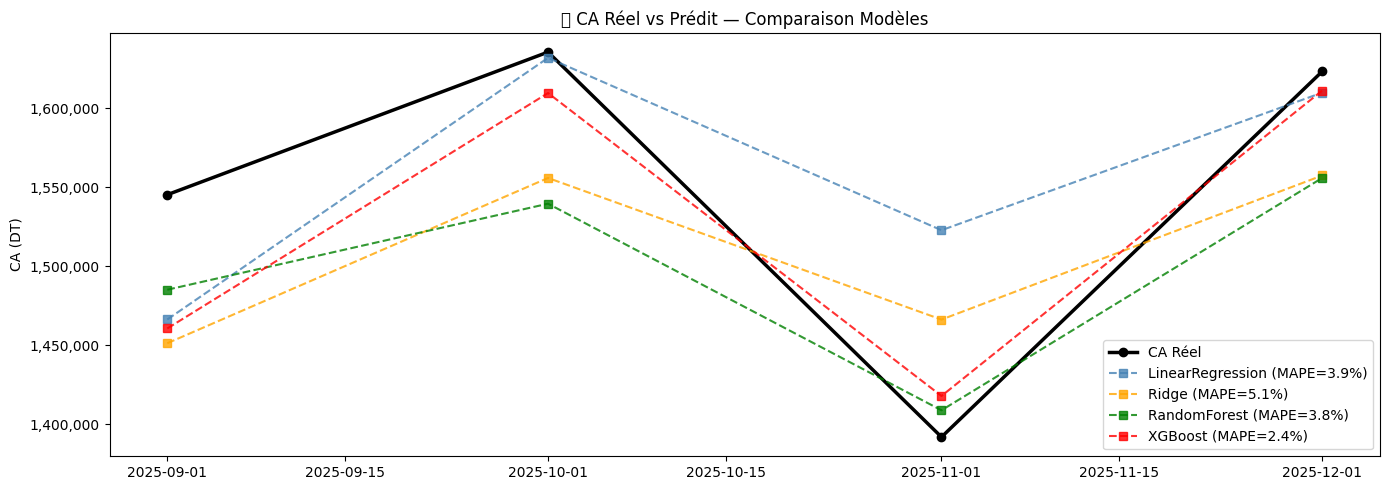

In [69]:
fig, ax = plt.subplots()

ax.plot(df_test['date'], y_test.values,
        label='CA Réel', color='black', marker='o', linewidth=2.5)

colors = ['steelblue', 'orange', 'green', 'red', 'purple']
for (_, row), color in zip(df_results.iterrows(), colors):
    ax.plot(df_test['date'], row['pred'],
            label=f"{row.name} (MAPE={row['MAPE']:.1f}%)",
            marker='s', linestyle='--', color=color, alpha=0.8)

ax.set_title('📈 CA Réel vs Prédit — Comparaison Modèles')
ax.set_ylabel('CA (DT)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

In [70]:
best = df_results.loc[best_name]

df_detail = df_test[['date']].copy()
df_detail['reel']   = y_test.values
df_detail['predit'] = best['pred']
df_detail['ecart']  = best['pred'] - y_test.values
df_detail['ecart%'] = (df_detail['ecart'] / df_detail['reel'] * 100).round(2)

print(f"=== Détail {best_name} ===\n")
print(df_detail.to_string(index=False))
print(f"\nBiais : {best['Biais']:,.2f} DT  ({'surestimation' if best['Biais'] > 0 else 'sous-estimation'})")

=== Détail XGBoost ===

      date         reel       predit      ecart  ecart%
2025-09-01 1,545,185.37 1,460,606.38 -84,579.00   -5.47
2025-10-01 1,635,378.39 1,609,483.38 -25,895.02   -1.58
2025-11-01 1,391,948.18 1,417,917.75  25,969.57    1.87
2025-12-01 1,623,158.26 1,611,061.75 -12,096.51   -0.75

Biais : -24,150.24 DT  (sous-estimation)


In [71]:
import joblib

# Réentraîner sur TOUT le dataset
print(f"Réentraînement sur {len(X)} mois complets...")
scaler_final = StandardScaler()

if best_name in ['LinearRegression', 'Ridge']:
    X_full_sc    = scaler_final.fit_transform(X)
    model_final  = type(best['model'])(**best['model'].get_params())
    model_final.fit(X_full_sc, y)
else:
    model_final = type(best['model'])(**best['model'].get_params())
    model_final.fit(X, y)
    scaler_final = scaler  # pas utilisé mais sauvegardé pour cohérence

joblib.dump(model_final,  '/app/notebooks/best_model.pkl')
joblib.dump(scaler_final, '/app/notebooks/scaler.pkl')

with open('/app/notebooks/best_model_name.json', 'w') as f:
    json.dump({'name': best_name, 'mape': float(best['MAPE'])}, f)

with open('/app/notebooks/features_corr.json', 'w') as f:
    json.dump(list(FEATURES), f)

print(f"✅ Modèle final sauvegardé : {best_name}")
print(f"   Entraîné sur : {len(X)} mois")
print(f"   MAPE test    : {best['MAPE']:.2f}%")

Réentraînement sur 36 mois complets...
✅ Modèle final sauvegardé : XGBoost
   Entraîné sur : 36 mois
   MAPE test    : 2.42%


## Prédiction — 12 mois futurs (Fév 2026 → Jan 2027)
### Variables contemporaines estimées par moyenne du même mois (années passées)

In [72]:
import plotly.graph_objects as go

# ── Configuration ─────────────────────────────────────────────
CONTEMPORAINES = [c for c in ['nb_clients', 'nb_documents', 'total_quantity']
                  if c in FEATURES]
use_scaler     = best_name in ['LinearRegression', 'Ridge']

df_future = df_ml.copy()
last_date = df_future['date'].max()
all_sales = list(df_future['total_sales'])

print(f'Modèle utilisé : {best_name}')
print(f'Départ         : {last_date.strftime("%b %Y")}')
print(f'Objectif       : Fév 2026 → Jan 2027')
print(f'Contemporaines : {CONTEMPORAINES}\n')

predictions = []

for i in range(1, 13):
    next_date  = last_date + pd.DateOffset(months=i)
    next_month = next_date.month
    next_year  = next_date.year

    row = {}

    # ── Features temporelles ──────────────────────────────
    if 'year'        in FEATURES: row['year']        = next_year
    if 'month'       in FEATURES: row['month']       = next_month
    if 'quarter'     in FEATURES: row['quarter']     = (next_month - 1) // 3 + 1
    if 'semester'    in FEATURES: row['semester']    = 1 if next_month <= 6 else 2
    if 'is_summer'   in FEATURES: row['is_summer']   = 1 if next_month in [7, 8] else 0
    if 'is_end_year' in FEATURES: row['is_end_year'] = 1 if next_month in [11, 12] else 0
    if 'is_january'  in FEATURES: row['is_january']  = 1 if next_month == 1 else 0

    # ── Lag features ─────────────────────────────────────
    if 'lag_1'  in FEATURES: row['lag_1']  = all_sales[-1]
    if 'lag_12' in FEATURES:
        # lag_12 → valeur réelle du même mois l'année précédente depuis all_sales
        row['lag_12'] = all_sales[-12] if len(all_sales) >= 12 else np.mean(all_sales)

    # ── Rolling features ──────────────────────────────────
    if 'rolling_mean_3' in FEATURES:
        row['rolling_mean_3'] = np.mean(all_sales[-3:])

    # ── Variables contemporaines ──────────────────────────
    # Moyenne du même mois sur les années passées
    # Ex: Juillet 2026 → moyenne des Juillet 2022/2023/2024/2025
    for col in CONTEMPORAINES:
        same_month_vals = df_future[df_future['month'] == next_month][col]
        row[col] = same_month_vals.mean() if len(same_month_vals) > 0 else df_future[col].mean()

    # ── Prédiction ────────────────────────────────────────
    X_row = pd.DataFrame([row])[FEATURES]
    if use_scaler:
        pred = model_final.predict(scaler_final.transform(X_row))[0]
    else:
        pred = model_final.predict(X_row)[0]

    all_sales.append(pred)
    predictions.append({
        'date':            next_date,
        'year':            next_year,
        'month':           next_month,
        'predicted_sales': pred,
        'is_prediction':   1
    })
    print(f'  {next_date.strftime("%b %Y")} → {pred:>15,.2f} DT')

df_pred = pd.DataFrame(predictions)
print(f'\n✅ {len(df_pred)} mois prédits')
print(f'CA prévisionnel total : {df_pred["predicted_sales"].sum():,.2f} DT')

Modèle utilisé : XGBoost
Départ         : Dec 2025
Objectif       : Fév 2026 → Jan 2027
Contemporaines : ['nb_clients', 'nb_documents', 'total_quantity']

  Jan 2026 →    1,102,545.75 DT
  Feb 2026 →    1,081,058.75 DT
  Mar 2026 →    1,135,972.38 DT
  Apr 2026 →    1,058,716.75 DT
  May 2026 →    1,319,731.88 DT
  Jun 2026 →    1,125,830.50 DT
  Jul 2026 →    1,381,584.12 DT
  Aug 2026 →    1,210,225.50 DT
  Sep 2026 →    1,390,785.38 DT
  Oct 2026 →    1,410,527.50 DT
  Nov 2026 →    1,363,689.00 DT
  Dec 2026 →    1,412,435.25 DT

✅ 12 mois prédits
CA prévisionnel total : 14,993,102.00 DT


## Visualisation — CA Réel + Prédit sur un seul graphe

In [73]:
fig = go.Figure()

# CA réel
fig.add_trace(go.Scatter(
    x=df_ml['date'], y=df_ml['total_sales'],
    name='CA Réel', mode='lines+markers',
    line=dict(color='steelblue', width=2), marker=dict(size=5)
))

# CA prédit
fig.add_trace(go.Scatter(
    x=df_pred['date'], y=df_pred['predicted_sales'],
    name=f'CA Prédit ({best_name})',
    mode='lines+markers',
    line=dict(color='orange', width=2, dash='dash'),
    marker=dict(size=6, symbol='square')
))

fig.add_vline(
    x=last_date.timestamp() * 1000,
    line_dash='dot', line_color='red',
    annotation_text=f'{last_date.strftime("%b %Y")} — Fin données réelles'
)

fig.update_layout(
    title=f'📈 CA Réel (Jan 2022 → Jan 2026) + Prédit (Fév 2026 → Jan 2027) — {best_name}',
    xaxis_title='Mois', yaxis_title='CA (DT)',
    hovermode='x unified', height=500
)
fig.show()

## CA annuel prévu vs réel

📋 PRÉVISION CA ANNUEL
CA réel 2024       :   15,843,689.48 DT
CA réel 2025       :   16,342,751.14 DT
CA prévu 2026-2027 :   14,993,102.00 DT
Croissance prévue  :           -8.26 %
Modèle             : XGBoost
MAPE test          : 2.42%

Détail mensuel :
      date  predicted_sales
2026-01-01     1,102,545.75
2026-02-01     1,081,058.75
2026-03-01     1,135,972.38
2026-04-01     1,058,716.75
2026-05-01     1,319,731.88
2026-06-01     1,125,830.50
2026-07-01     1,381,584.12
2026-08-01     1,210,225.50
2026-09-01     1,390,785.38
2026-10-01     1,410,527.50
2026-11-01     1,363,689.00
2026-12-01     1,412,435.25


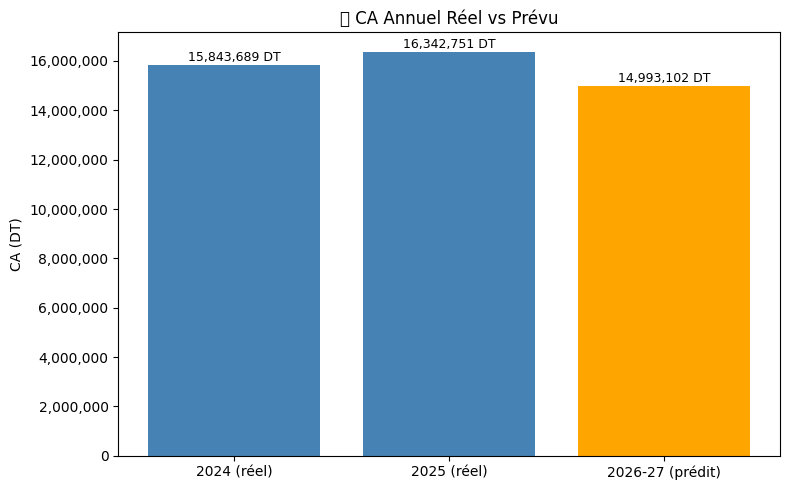

In [74]:
ca_prevu  = df_pred['predicted_sales'].sum()
ca_2025   = df_ml[df_ml['date'].dt.year == 2025]['total_sales'].sum()
ca_2024   = df_ml[df_ml['date'].dt.year == 2024]['total_sales'].sum()
croissance = (ca_prevu - ca_2025) / ca_2025 * 100

print('=' * 55)
print('📋 PRÉVISION CA ANNUEL')
print('=' * 55)
print(f'CA réel 2024       : {ca_2024:>15,.2f} DT')
print(f'CA réel 2025       : {ca_2025:>15,.2f} DT')
print(f'CA prévu 2026-2027 : {ca_prevu:>15,.2f} DT')
print(f'Croissance prévue  : {croissance:>15.2f} %')
print(f'Modèle             : {best_name}')
print(f'MAPE test          : {best["MAPE"]:.2f}%')
print('=' * 55)
print('\nDétail mensuel :')
print(df_pred[['date', 'predicted_sales']].to_string(index=False))

# Graphe annuel
years_data = pd.DataFrame([
    {'Année': '2024 (réel)',     'CA': ca_2024},
    {'Année': '2025 (réel)',     'CA': ca_2025},
    {'Année': '2026-27 (prédit)','CA': ca_prevu},
])
fig, ax = plt.subplots(figsize=(8, 5))
colors  = ['steelblue', 'steelblue', 'orange']
ax.bar(years_data['Année'], years_data['CA'], color=colors)
for i, (_, r) in enumerate(years_data.iterrows()):
    ax.text(i, r['CA'] + years_data['CA'].max() * 0.01,
            f"{r['CA']:,.0f} DT", ha='center', fontsize=9)
ax.set_title('📊 CA Annuel Réel vs Prévu')
ax.set_ylabel('CA (DT)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

## Écriture dans ClickHouse Gold

In [75]:
client2 = clickhouse_connect.get_client(
    host='clickhouse', port=8123,
    user='default', password='clickhouse123',
    database='gold'
)

client2.command("""
    CREATE TABLE IF NOT EXISTS gold.ml_predictions (
        date             Date,
        year             Int32,
        month            Int32,
        predicted_sales  Float64,
        is_prediction    Int8
    )
    ENGINE = MergeTree()
    ORDER BY date
""")

client2.command('TRUNCATE TABLE gold.ml_predictions')
client2.insert_df('gold.ml_predictions',
    df_pred[['date', 'year', 'month', 'predicted_sales', 'is_prediction']])

check = client2.query_df('SELECT * FROM gold.ml_predictions ORDER BY date')
print(f'✅ {len(check)} prédictions écrites dans ClickHouse Gold')
print('   Table : gold.ml_predictions\n')
print(check.to_string(index=False))

✅ 12 prédictions écrites dans ClickHouse Gold
   Table : gold.ml_predictions

      date  year  month  predicted_sales  is_prediction
2026-01-01  2026      1     1,102,545.75              1
2026-02-01  2026      2     1,081,058.75              1
2026-03-01  2026      3     1,135,972.38              1
2026-04-01  2026      4     1,058,716.75              1
2026-05-01  2026      5     1,319,731.88              1
2026-06-01  2026      6     1,125,830.50              1
2026-07-01  2026      7     1,381,584.12              1
2026-08-01  2026      8     1,210,225.50              1
2026-09-01  2026      9     1,390,785.38              1
2026-10-01  2026     10     1,410,527.50              1
2026-11-01  2026     11     1,363,689.00              1
2026-12-01  2026     12     1,412,435.25              1
